In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder


plt.style.use("ggplot")
df = pd.read_csv("Sales Dataset.csv")
print(df.head())


   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  05-02-2010      24924.50      False        42.31       2.572   
1      1     1  12-02-2010      46039.49       True        38.51       2.548   
2      1     1  19-02-2010      41595.55      False        39.93       2.514   
3      1     1  26-02-2010      19403.54      False        46.63       2.561   
4      1     1  05-03-2010      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  15

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(421570, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB
None
      

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

print(missing)

              Missing Values  Percentage
Store                      0        0.00
Dept                       0        0.00
Date                       0        0.00
Weekly_Sales               0        0.00
IsHoliday                  0        0.00
Temperature                0        0.00
Fuel_Price                 0        0.00
MarkDown1             270889       64.26
MarkDown2             310322       73.61
MarkDown3             284479       67.48
MarkDown4             286603       67.98
MarkDown5             270138       64.08
CPI                        0        0.00
Unemployment               0        0.00
Type                       0        0.00
Size                       0        0.00


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate Rows : 0


In [ ]:
markdown = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

for col in markdown:
    df[col] = df[col].fillna(0)

In [ ]:
df["CPI"] = df["CPI"].fillna(df["CPI"].median())
df["Unemployment"] = df["Unemployment"].fillna(df["Unemployment"].median())
df["Temperature"] = df["Temperature"].fillna(df["Temperature"].median())
df["Fuel_Price"] = df["Fuel_Price"].fillna(df["Fuel_Price"].median())

print(df.isnull().sum())

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

print(df.head())
print(df.dtypes)

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358   
1        0.0        0.0        0.0        0.0        0.0  211.242170   
2       

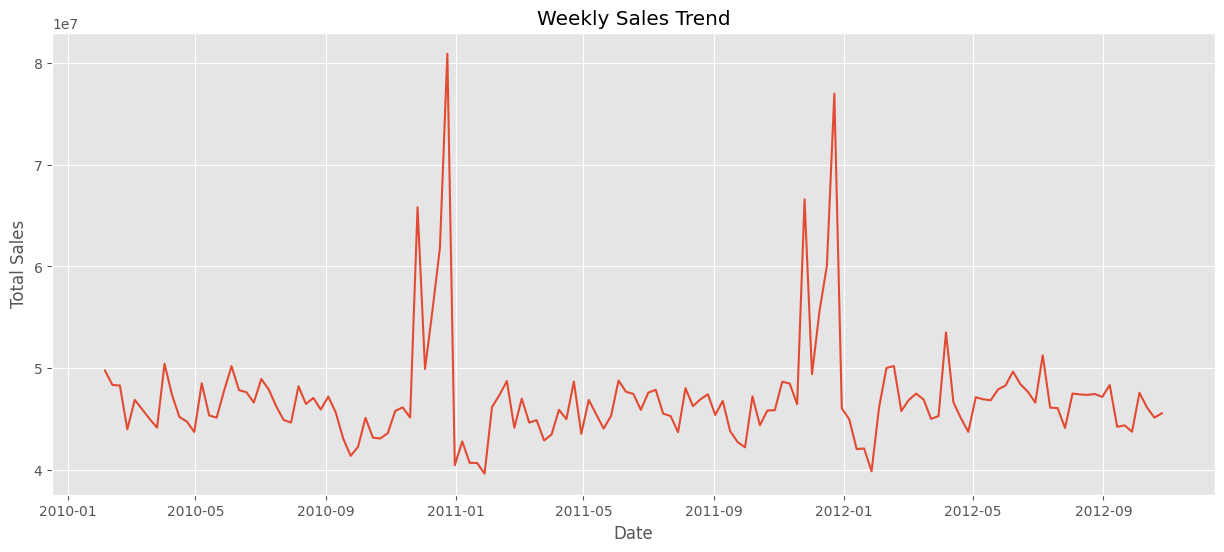

In [ ]:
##Weekly Sales Trend
sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(15,6))

plt.plot(
    sales.index,
    sales.values
)

plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

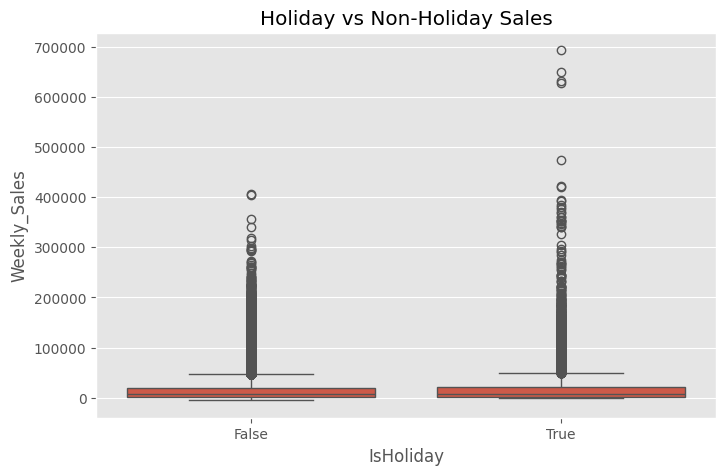

In [ ]:
##Holiday vs Non-Holiday Sales
plt.figure(figsize=(8,5))

sns.boxplot(
    x="IsHoliday",
    y="Weekly_Sales",
    data=df
)

plt.title("Holiday vs Non-Holiday Sales")
plt.show()

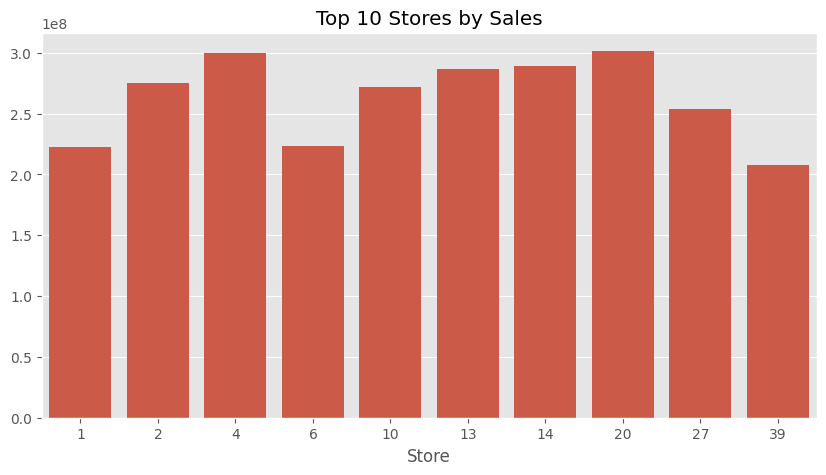

In [ ]:
##Top 10 Stores
top_store = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_store.index,
    y=top_store.values
)

plt.title("Top 10 Stores by Sales")
plt.show()

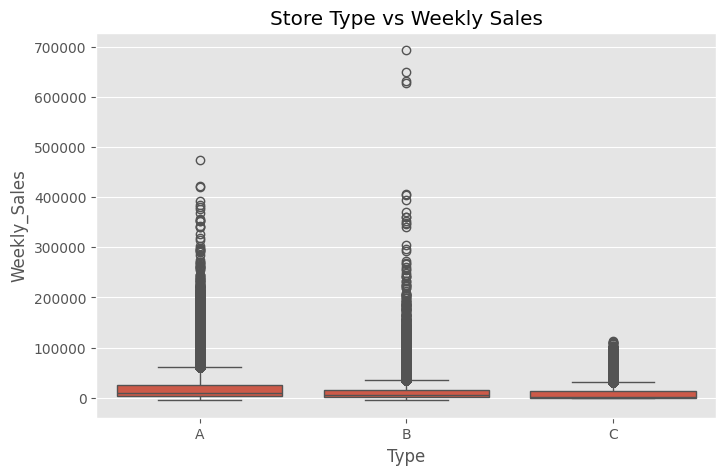

In [ ]:
##Store Type Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Type",
    y="Weekly_Sales",
    data=df
)

plt.title("Store Type vs Weekly Sales")
plt.show()

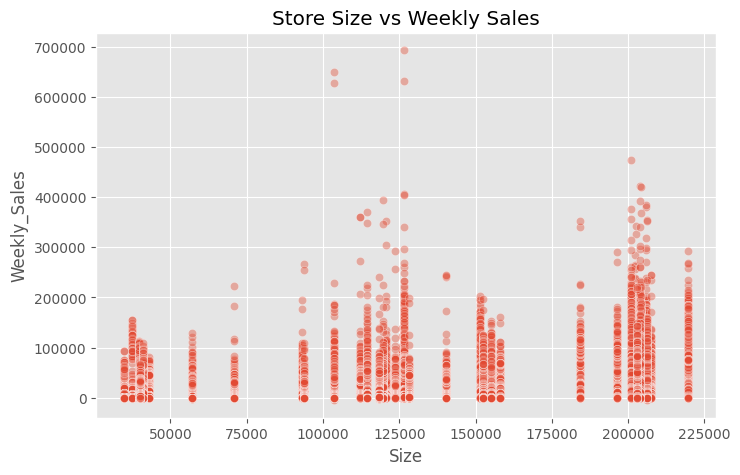

In [ ]:
##Store Size vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Size",
    y="Weekly_Sales",
    data=df,
    alpha=0.4
)

plt.title("Store Size vs Weekly Sales")
plt.show()

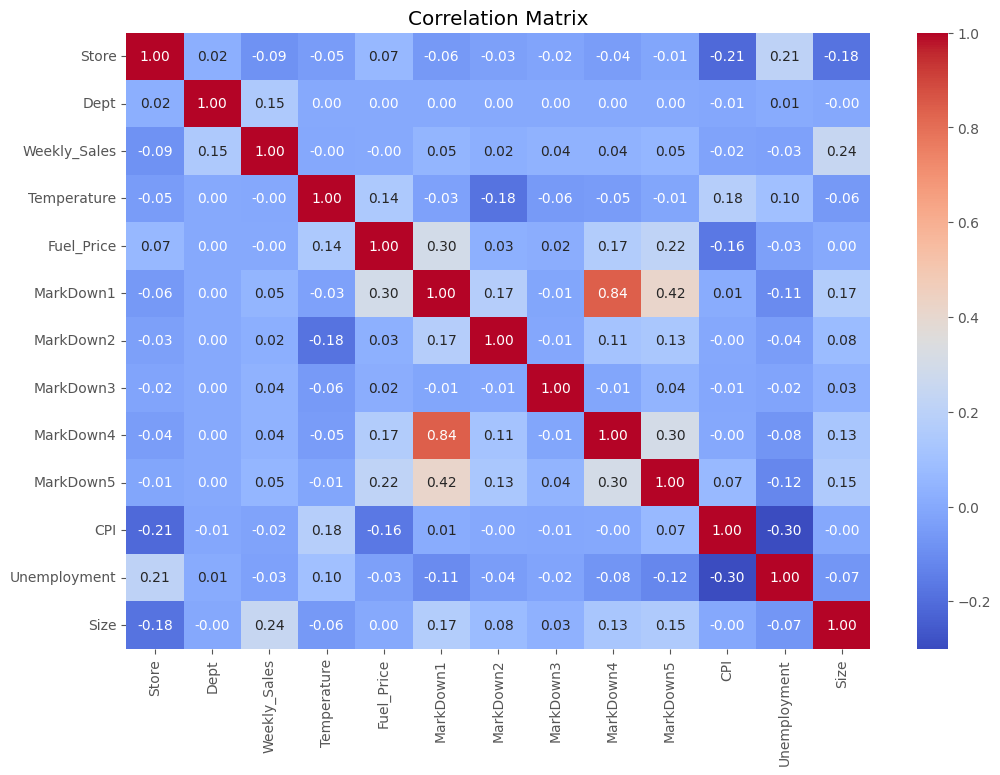

In [ ]:
##Correlation Heatmap
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

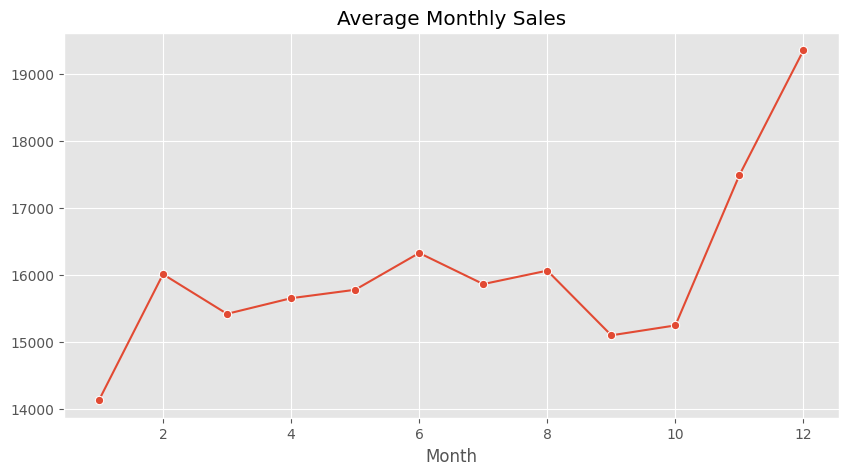

In [ ]:
##Monthly Sales Trend
df["Month"] = df["Date"].dt.month

monthly = (
    df.groupby("Month")["Weekly_Sales"]
      .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o"
)

plt.title("Average Monthly Sales")

plt.show()

In [ ]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------
# Date Features
# -----------------------------
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

# -----------------------------
# Sort Data
# -----------------------------
df = df.sort_values(["Store","Dept","Date"])

# -----------------------------
# Lag Features
# -----------------------------
df["Lag_1"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .shift(1)
)

df["Lag_2"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .shift(2)
)

df["Lag_4"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .shift(4)
)

# -----------------------------
# Moving Average
# -----------------------------
df["MA_4"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .rolling(4)
      .mean()
      .reset_index(level=[0,1],drop=True)
)

# -----------------------------
# Rolling Standard Deviation
# -----------------------------
df["Rolling_STD_4"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .rolling(4)
      .std()
      .reset_index(level=[0,1],drop=True)
)

# -----------------------------
# Encode Store Type
# -----------------------------
encoder = LabelEncoder()

df["Type"] = encoder.fit_transform(df["Type"])

# Convert Holiday Boolean to Integer
df["IsHoliday"] = df["IsHoliday"].astype(int)

# Remove NaN & Infinity
df.replace([np.inf,-np.inf],np.nan,inplace=True)

df.dropna(inplace=True)

print(df.shape)

df.to_csv("Walmart_Feature_Engineered.csv",index=False)

(382955, 25)


               Model          MAE         RMSE        R2
0  Linear Regression  1401.001139  3125.103944  0.980081
1      Random Forest   976.881357  2282.219186  0.989377
2  Gradient Boosting  1378.616222  2910.591603  0.982722
               Model          MAE         RMSE        R2
1      Random Forest   976.881357  2282.219186  0.989377
2  Gradient Boosting  1378.616222  2910.591603  0.982722
0  Linear Regression  1401.001139  3125.103944  0.980081
               Model          MAE         RMSE        R2
0  Linear Regression  1401.001139  3125.103944  0.980081
1      Random Forest   976.881357  2282.219186  0.989377
2  Gradient Boosting  1378.616222  2910.591603  0.982722
               Model          MAE         RMSE        R2
1      Random Forest   976.881357  2282.219186  0.989377
2  Gradient Boosting  1378.616222  2910.591603  0.982722
0  Linear Regression  1401.001139  3125.103944  0.980081


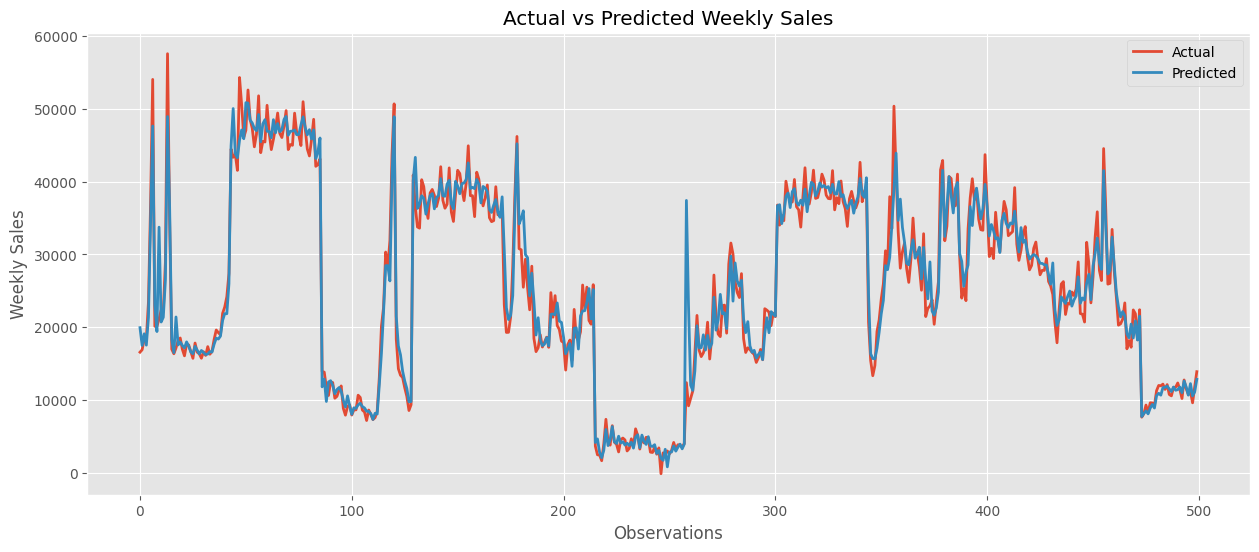

          Feature  Importance
21           MA_4    0.939885
22  Rolling_STD_4    0.016490
18          Lag_1    0.009999
19          Lag_2    0.009103
16           Week    0.005478
2       IsHoliday    0.004562
20          Lag_4    0.004370
7       MarkDown3    0.002947
1            Dept    0.001570
10            CPI    0.000946
3     Temperature    0.000944
15          Month    0.000815
4      Fuel_Price    0.000613
11   Unemployment    0.000574
13           Size    0.000481
0           Store    0.000381
8       MarkDown4    0.000170
9       MarkDown5    0.000151
6       MarkDown2    0.000129
17        Quarter    0.000119
5       MarkDown1    0.000110
12           Type    0.000104
14           Year    0.000061


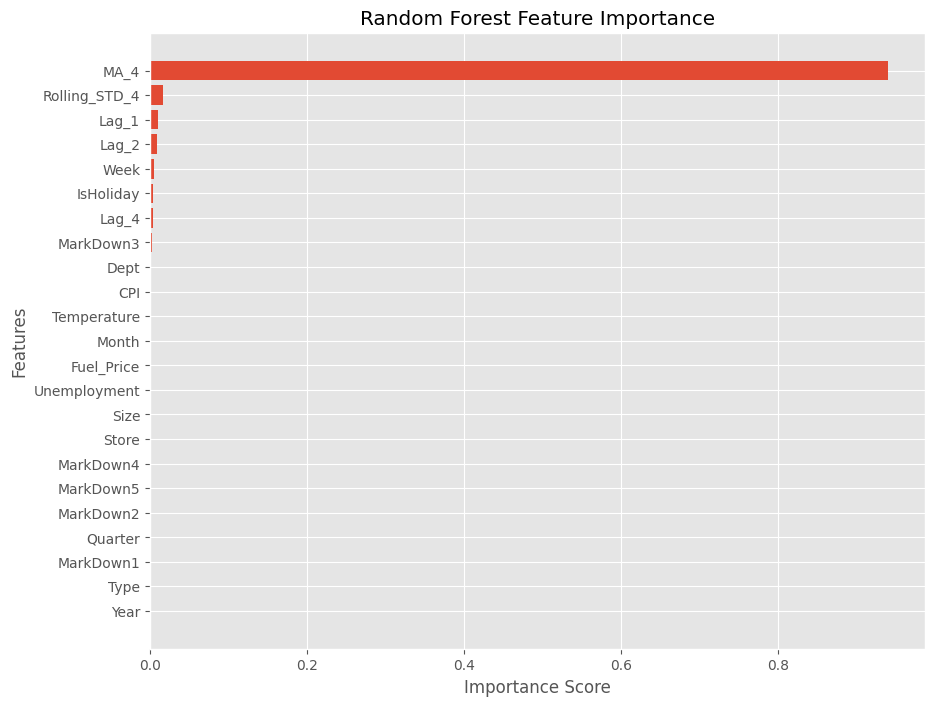

Files Saved Successfully
          Date  Store  Dept  Actual_Sales  Predicted_Sales
100 2012-01-06      1     1      16567.69      19935.91000
101 2012-01-13      1     1      16894.40      17493.18420
102 2012-01-20      1     1      18365.10      19096.22125
103 2012-01-27      1     1      18378.16      17533.98360
104 2012-02-03      1     1      23510.49      21357.27070
105 2012-02-10      1     1      36988.49      34423.64765
106 2012-02-17      1     1      54060.10      47650.45865
107 2012-02-24      1     1      20124.22      23013.87820
108 2012-03-02      1     1      20113.03      19403.00130
109 2012-03-09      1     1      21140.07      33749.86770
110 2012-03-16      1     1      22366.88      20714.63965
111 2012-03-23      1     1      22107.70      21360.78440
112 2012-03-30      1     1      28952.86      26463.87180
113 2012-04-06      1     1      57592.12      48952.53225
114 2012-04-13      1     1      34684.21      36410.65125
115 2012-04-20      1     1    

In [ ]:
features = ["Store","Dept","IsHoliday","Temperature","Fuel_Price","MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5","CPI","Unemployment","Type","Size",
            "Year","Month","Week","Quarter", "Lag_1","Lag_2","Lag_4","MA_4","Rolling_STD_4"]

target = "Weekly_Sales"

X = df[features]
y = df[target]

train = df[df["Date"] < "2012-01-01"]

test = df[df["Date"] >= "2012-01-01"]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

gbr = GradientBoostingRegressor(

    n_estimators=200,

    learning_rate=0.05,

    random_state=42

)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

def evaluate(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return [model_name, mae, rmse, r2]

results = []

results.append(
    evaluate(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate(
        "Gradient Boosting",
        y_test,
        gbr_pred
    )
)

results = pd.DataFrame(

    results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]

)

print(results)

best = results.sort_values(

    by="R2",

    ascending=False

)

print(best)

br = GradientBoostingRegressor(

    n_estimators=200,

    learning_rate=0.05,

    random_state=42

)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

def evaluate(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return [model_name, mae, rmse, r2]
results = []

results.append(
    evaluate(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate(
        "Gradient Boosting",
        y_test,
        gbr_pred
    )
)

results = pd.DataFrame(

    results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]

)

print(results)

best = results.sort_values(

    by="R2",

    ascending=False

)

print(best)

plt.figure(figsize=(15,6))

plt.plot(

    y_test.values[:500],

    label="Actual",

    linewidth=2

)

plt.plot(

    rf_pred[:500],

    label="Predicted",

    linewidth=2

)

plt.title("Actual vs Predicted Weekly Sales")

plt.xlabel("Observations")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

importance = pd.DataFrame({

    "Feature": features,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print(importance)

plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

results.to_csv(
    "Model_Comparison.csv",
    index=False
)

importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

print("Files Saved Successfully")

future_predictions = test[["Date","Store","Dept"]].copy()

future_predictions["Actual_Sales"] = y_test.values

future_predictions["Predicted_Sales"] = rf_pred

print(future_predictions.head(20))

future_predictions.to_csv(

    "Weekly_Sales_Predictions.csv",

    index=False

)

print("Prediction File Saved Successfully")